
Final Results:

Sphere: Best=0.0079, Mean=0.0251, Std=0.0095
Rastrigin: Best=3.2695, Mean=7.4541, Std=3.0622
Rosenbrock: Best=3.0057, Mean=4.3992, Std=1.0078
Ackley: Best=0.1832, Mean=0.4643, Std=0.2030


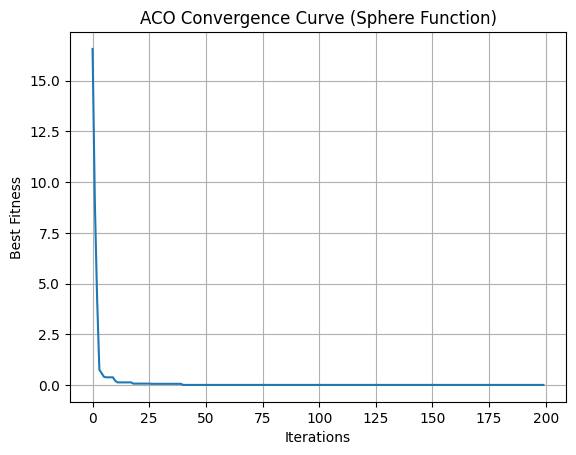

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return np.sum(x**2 - 10*np.cos(2*np.pi*x) + 10)

def rosenbrock(x):
    return np.sum(100*(x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)

def ackley(x):
    n = len(x)
    return -20*np.exp(-0.2*np.sqrt(np.sum(x**2)/n)) - np.exp(np.sum(np.cos(2*np.pi*x))/n) + 20 + np.e

class ACO:
    def __init__(self, func, dim, bounds, ants=30, iterations=200):
        self.func = func
        self.dim = dim
        self.lb, self.ub = bounds
        self.ants = ants
        self.iterations = iterations
        self.history = []

    def optimize(self):
        solutions = np.random.uniform(self.lb, self.ub, (self.ants, self.dim))
        fitness = np.array([self.func(s) for s in solutions])

        best = solutions[np.argmin(fitness)]
        best_score = np.min(fitness)

        for _ in range(self.iterations):
            new_solutions = []

            for _ in range(self.ants):
                sigma = (self.ub - self.lb) * 0.05
                new = best + np.random.normal(0, sigma, self.dim)
                new = np.clip(new, self.lb, self.ub)
                new_solutions.append(new)

            new_solutions = np.array(new_solutions)
            new_fitness = np.array([self.func(s) for s in new_solutions])

            all_solutions = np.vstack((solutions, new_solutions))
            all_fitness = np.hstack((fitness, new_fitness))

            idx = np.argsort(all_fitness)[:self.ants]
            solutions = all_solutions[idx]
            fitness = all_fitness[idx]

            if fitness[0] < best_score:
                best = solutions[0]
                best_score = fitness[0]

            self.history.append(best_score)

        return best_score

def run_multiple(func, runs=10):
    results = []
    for _ in range(runs):
        aco = ACO(func, dim=5, bounds=(-5, 5), ants=30, iterations=200)
        best = aco.optimize()
        results.append(best)
    return np.min(results), np.mean(results), np.std(results)

functions = {
    "Sphere": sphere,
    "Rastrigin": rastrigin,
    "Rosenbrock": rosenbrock,
    "Ackley": ackley
}

final_results = {}

for name, func in functions.items():
    best, mean, std = run_multiple(func)
    final_results[name] = (best, mean, std)

print("\nFinal Results:\n")
for k, v in final_results.items():
    print(f"{k}: Best={v[0]:.4f}, Mean={v[1]:.4f}, Std={v[2]:.4f}")

aco = ACO(sphere, dim=5, bounds=(-5, 5), ants=30, iterations=200)
aco.optimize()

plt.plot(aco.history)
plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("ACO Convergence Curve (Sphere Function)")
plt.grid()
plt.show()